In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone
from IPython.display import display


def unpack_bits_from_uint32(sample_data_u32, num_variables, bitorder="little"):
    arr = np.asarray(sample_data_u32, dtype=np.uint32)
    raw_bytes = arr.astype("<u4", copy=False).view(np.uint8)
    raw_bytes = raw_bytes.reshape(arr.shape[0], arr.shape[1] * 4)
    bits = np.unpackbits(raw_bytes, axis=1, bitorder=bitorder)
    return bits[:, :num_variables].astype(np.uint8)

def cargar_meta_qubo(json_meta):
    with open(json_meta, "r", encoding="utf-8") as f:
        obj = json.load(f)

    N = int(obj["N"])
    K = int(obj.get("K", 1))
    ciudades = list(obj["ciudades"])
    n_slots = int(obj["n_slots"])
    indices_depositos = list(obj["origenes_indx"])

    varmap_raw = obj["varmap"]

    varmap = {}
    for k, v in varmap_raw.items():
        idx = int(k)

        if len(v) == 3:
            # Formato: [vehiculo, ciudad, slot]
            vehiculo, ciudad, slot = int(v[0]), int(v[1]), int(v[2])

        elif len(v) == 2:
            # Formato: [ciudad, slot] -> asumimos un único vehículo
            vehiculo, ciudad, slot = 0, int(v[0]), int(v[1])

        else:
            raise ValueError(
                f"Formato inesperado en varmap para clave {k}: {v}"
            )

        varmap[idx] = (vehiculo, ciudad, slot)

    if len(varmap) != N:
        raise ValueError(f"len(varmap)={len(varmap)} != N={N}")

    return {
        "N": N,
        "K": K,
        "ciudades": ciudades,
        "n_slots": n_slots,
        "indices_depositos": indices_depositos,
        "varmap": varmap,
        "raw": obj,
    }

def asegurar_bits(bits, N):
    bits = np.asarray(bits, dtype=int).ravel()
    if bits.size != N:
        raise ValueError(f"Tamaño de bits {bits.size} != N ({N})")
    return bits


def reconstruir_X_3d(bits, varmap, n_ciudades, K, n_slots):
    """
    X[k, i, t] = activación del vehículo k en la ciudad i y slot t
    """
    bits = asegurar_bits(bits, len(varmap))
    X = np.zeros((K, n_ciudades, n_slots), dtype=int)

    for q, (k, i, t) in varmap.items():
        if q < bits.size:
            X[k, i, t] += int(bits[q])

    return X


def comprimir_consecutivos(seq):
    out = []
    for x in seq:
        if not out or out[-1] != x:
            out.append(x)
    return out

def decodificar_rutas_por_vehiculo(bits, varmap, ciudades, K, n_slots):
    """
    Decodifica una ruta por vehículo usando argmax por slot.
    """
    n_ciudades = len(ciudades)
    X = reconstruir_X_3d(bits, varmap, n_ciudades, K, n_slots)

    rutas_idx = []
    rutas_txt = []

    for k in range(K):
        seq_k = [int(np.argmax(X[k, :, t])) for t in range(n_slots)]
        seq_k = comprimir_consecutivos(seq_k)
        rutas_idx.append(seq_k)
        rutas_txt.append(" -> ".join(ciudades[i] for i in seq_k))

    return rutas_idx, rutas_txt, X

def evaluar_factibilidad_basica(bits, varmap, ciudades, K, n_slots, indices_depositos):
    """
    Criterio básico:
      - 1 ciudad por (vehículo, slot)
      - cada ciudad NO depósito aparece exactamente una vez en total
    """
    n_ciudades = len(ciudades)
    X = reconstruir_X_3d(bits, varmap, n_ciudades, K, n_slots)
    depot_set = set(indices_depositos)

    # una ciudad por vehículo y slot
    por_vehiculo_slot = X.sum(axis=1)  # shape (K, n_slots)
    viol_slot = int(np.sum(por_vehiculo_slot != 1))

    # cada no-depósito exactamente una vez globalmente
    por_ciudad = X.sum(axis=(0, 2))  # suma sobre vehículos y slots
    mask_no_dep = np.ones(n_ciudades, dtype=bool)
    for d in depot_set:
        if 0 <= d < n_ciudades:
            mask_no_dep[d] = False

    viol_ciudad = int(np.sum(por_ciudad[mask_no_dep] != 1))

    factible = (viol_slot == 0) and (viol_ciudad == 0)

    return {
        "factible": bool(factible),
        "viol_slot": viol_slot,
        "viol_ciudad": viol_ciudad,
    }

def heatmap_rutas(data, top_n=40, solo_factibles=True, fallback_a_todas=True):
    """
    Heatmap ciudad x slot, agregando todos los vehículos.
    Si no hay factibles y fallback_a_todas=True, usa todas las respuestas.
    """
    registros = []
    for i, (bits, e, occ) in enumerate(zip(data["bits"], data["energies"], data["num_occurrences"])):
        fac = evaluar_factibilidad_basica(
            bits,
            data["varmap"],
            data["ciudades"],
            data["K"],
            data["n_slots"],
            data["indices_depositos"],
        )
        registros.append((i, e, occ, fac["factible"], fac["viol_slot"], fac["viol_ciudad"]))

    df_idx = pd.DataFrame(
        registros,
        columns=["idx", "energia", "ocurrencias", "factible", "viol_slot", "viol_ciudad"]
    )

    n_factibles = int(df_idx["factible"].sum())
    print(f"Total respuestas: {len(df_idx)}")
    print(f"Factibles: {n_factibles}")
    print(f"No factibles: {len(df_idx) - n_factibles}")

    usando_factibles = solo_factibles

    if solo_factibles:
        df_sel = df_idx[df_idx["factible"]].copy()

        if len(df_sel) == 0:
            if fallback_a_todas:
                print("No hay respuestas factibles con el criterio actual; usando todas para el heatmap.")
                df_sel = df_idx.copy()
                usando_factibles = False
            else:
                raise ValueError("No hay respuestas para el heatmap con ese filtro.")
    else:
        df_sel = df_idx.copy()

    df_sel = df_sel.sort_values(["energia", "ocurrencias"], ascending=[True, False]).head(top_n)

    if len(df_sel) == 0:
        raise ValueError("No hay respuestas disponibles para construir el heatmap.")

    W = df_sel["ocurrencias"].to_numpy(dtype=float)
    W = W / W.sum() if W.sum() > 0 else np.ones(len(W)) / len(W)

    H = np.zeros((len(data["ciudades"]), data["n_slots"]), dtype=float)

    for idx, w in zip(df_sel["idx"].to_numpy(), W):
        bits = data["bits"][idx]
        _, _, X = decodificar_rutas_por_vehiculo(
            bits,
            data["varmap"],
            data["ciudades"],
            data["K"],
            data["n_slots"],
        )

        # X tiene shape (K, n_ciudades, n_slots)
        X2 = X.sum(axis=0)  # ciudad x slot
        H += w * X2

    plt.figure(figsize=(1.2 * data["n_slots"], 0.45 * len(data["ciudades"]) + 3))
    plt.imshow(H, aspect="auto", interpolation="nearest")
    plt.yticks(range(len(data["ciudades"])), data["ciudades"])
    plt.xticks(range(data["n_slots"]), [f"t={t}" for t in range(data["n_slots"])])
    plt.colorbar(label="Ocupación ponderada")
    plt.xlabel("Slot")
    plt.ylabel("Ciudad")
    plt.title(
        f"Heatmap de rutas ({'solo factibles' if usando_factibles else 'todas'}, top {len(df_sel)})"
    )
    plt.tight_layout()
    plt.show()

    return H, df_idx

def convertir_fecha_rfc3339(fecha_texto):
    if fecha_texto is None:
        return None
    if fecha_texto.endswith("Z"):
        fecha_texto = fecha_texto[:-1] + "+00:00"
    return datetime.fromisoformat(fecha_texto)

def cargar_resultados_dwave(json_resultados):
    """
    Carga resultados de D-Wave para backends classical_sa, hybrid y qpu.
    """
    with open(json_resultados, "r", encoding="utf-8") as f:
        objeto = json.load(f)

    sampleset = objeto["sampleset"]
    numero_variables = int(sampleset["num_variables"])
    muestras_empaquetadas = bool(sampleset.get("sample_packed", False))
    datos_muestras = np.asarray(sampleset["sample_data"]["data"], dtype=np.uint32)

    if muestras_empaquetadas:
        bits = unpack_bits_from_uint32(datos_muestras, numero_variables, bitorder="little")
    else:
        bits = np.asarray(datos_muestras, dtype=np.uint8)
        if bits.ndim != 2:
            raise ValueError("sample_data no tiene forma 2D.")
        bits = bits[:, :numero_variables]

    vectores = sampleset["vectors"]
    energias = np.asarray(vectores["energy"]["data"], dtype=float)
    ocurrencias = np.asarray(vectores["num_occurrences"]["data"], dtype=int)

    if "chain_break_fraction" in vectores:
        fraccion_rotura_cadena = np.asarray(vectores["chain_break_fraction"]["data"], dtype=float)
    else:
        fraccion_rotura_cadena = np.full(len(bits), np.nan)

    return {
        "backend": objeto["meta"]["backend"],
        "nombre_solver": objeto["meta"]["solver_name"],
        "tiempo_total_s": float(objeto["meta"].get("wallclock_s", np.nan)),
        "parametros": objeto["meta"].get("params", {}),
        "bits": bits,
        "energias": energias,
        "ocurrencias": ocurrencias,
        "fraccion_rotura_cadena": fraccion_rotura_cadena,
        "raw": objeto,
    }

def cargar_resultados_dirac3(json_resultados):
    """
    Carga resultados de Dirac-3.
    """
    with open(json_resultados, "r", encoding="utf-8") as f:
        objeto = json.load(f)

    ocurrencias = np.asarray(objeto["results"]["counts"], dtype=int)
    energias = np.asarray(objeto["results"]["energies"], dtype=float)
    bits = np.asarray(objeto["results"]["solutions"], dtype=np.uint8)

    estado_job = objeto["job_info"]["job_status"]
    fecha_inicio = convertir_fecha_rfc3339(estado_job.get("submitted_at_rfc3339nano"))
    fecha_fin = convertir_fecha_rfc3339(estado_job.get("completed_at_rfc3339nano"))
    tiempo_total_s = (fecha_fin - fecha_inicio).total_seconds() if (fecha_inicio and fecha_fin) else np.nan

    return {
        "backend": "dirac-3",
        "nombre_solver": "dirac-3_qudit",
        "tiempo_total_s": tiempo_total_s,
        "tiempo_uso_dispositivo_s": float(objeto["job_info"]["job_result"].get("device_usage_s", np.nan)),
        "parametros": objeto["job_info"]["job_submission"]["device_config"]["dirac-3_qudit"],
        "bits": bits,
        "energias": energias,
        "ocurrencias": ocurrencias,
        "fraccion_rotura_cadena": np.full(len(bits), np.nan),
        "raw": objeto,
    }

def inferir_metadatos_desde_nombre_archivo(ruta_resultados):
    """
    Intenta inferir método, problema, caso y tamaño a partir del nombre del archivo.
    """
    nombre = Path(ruta_resultados).stem

    if nombre.startswith("classical_sa"):
        metodo = "local"
    elif nombre.startswith("hybrid"):
        metodo = "hybrid"
    elif nombre.startswith("qpu"):
        metodo = "QPU"
    elif nombre.startswith("resp_") or nombre.startswith("dirac_"):
        metodo = "dirac-3"
    else:
        metodo = "desconocido"

    problema = None
    for nombre_problema in ["SinRestricciones", "DistintoOrigen", "MismoDeposito"]:
        if nombre_problema in nombre:
            problema = nombre_problema
            break

    caso = None
    for nombre_caso in ["A", "B", "C"]:
        if nombre.endswith(nombre_caso):
            caso = nombre_caso
            break

    if "70bits" in nombre or "70qubits" in nombre:
        tamaño = "media"
    elif "90bits" in nombre or "90qubits" in nombre:
        tamaño = "grande"
    else:
        tamaño = "pequeña"

    return metodo, problema, caso, tamaño

def cargar_ejecucion_completa(json_resultados, json_meta, metodo=None, problema=None, caso=None, tamaño=None):
    """
    Carga una ejecución completa, la decodifica y genera:
    - resumen global
    - dataframe de muestras
    - metadatos del QUBO
    """
    metodo_inferido, problema_inferido, caso_inferido, tamaño_inferido = inferir_metadatos_desde_nombre_archivo(json_resultados)

    metodo = metodo or metodo_inferido
    problema = problema or problema_inferido
    caso = caso or caso_inferido
    tamaño = tamaño or tamaño_inferido

    meta = cargar_meta_qubo(json_meta)

    if metodo == "dirac-3":
        resultados = cargar_resultados_dirac3(json_resultados)
    else:
        resultados = cargar_resultados_dwave(json_resultados)

    if resultados["bits"].shape[1] != meta["N"]:
        raise ValueError(
            f"Inconsistencia entre {json_resultados} ({resultados['bits'].shape[1]} bits) y meta N={meta['N']}"
        )

    filas = []
    for bits, energia, ocurrencias, fraccion_rotura in zip(
        resultados["bits"], resultados["energias"], resultados["ocurrencias"], resultados["fraccion_rotura_cadena"]
    ):
        rutas_indice, rutas_texto, matriz_solucion = decodificar_rutas_por_vehiculo(
            bits, meta["varmap"], meta["ciudades"], meta["K"], meta["n_slots"]
        )

        factibilidad = evaluar_factibilidad_basica(
            bits, meta["varmap"], meta["ciudades"], meta["K"], meta["n_slots"], meta["indices_depositos"]
        )

        filas.append({
            "metodo": metodo,
            "problema": problema,
            "caso": caso,
            "tamaño": tamaño,
            "N": meta["N"],
            "K": meta["K"],
            "energia": float(energia),
            "ocurrencias": int(ocurrencias),
            "factible": bool(factibilidad["factible"]),
            "violaciones_slot": int(factibilidad["viol_slot"]),
            "violaciones_ciudad": int(factibilidad["viol_ciudad"]),
            "fraccion_rotura_cadena": float(fraccion_rotura) if not np.isnan(fraccion_rotura) else np.nan,
            "ruta_texto": " || ".join([f"Vehículo {k}: {ruta}" for k, ruta in enumerate(rutas_texto)]),
            "bits": np.asarray(bits, dtype=np.uint8),
        })

    tabla_muestras = pd.DataFrame(filas)

    pesos = tabla_muestras["ocurrencias"].to_numpy(dtype=float)
    pesos = np.ones(len(tabla_muestras)) if pesos.sum() == 0 else pesos

    mascara_factibles = tabla_muestras["factible"].to_numpy(dtype=bool)
    if mascara_factibles.any():
        mejor_factible = tabla_muestras.loc[mascara_factibles].sort_values(
            ["energia", "ocurrencias"], ascending=[True, False]
        ).iloc[0]
        mejor_energia_factible = float(mejor_factible["energia"])
        mejor_ruta_factible = mejor_factible["ruta_texto"]
    else:
        mejor_energia_factible = np.nan
        mejor_ruta_factible = None

    energia_media = np.average(tabla_muestras["energia"], weights=pesos)
    desviacion_media = np.sqrt(np.average((tabla_muestras["energia"] - energia_media) ** 2, weights=pesos))

    resumen = {
        "metodo": metodo,
        "problema": problema,
        "caso": caso,
        "tamaño": tamaño,
        "N": meta["N"],
        "K": meta["K"],
        "tiempo_total_s": float(resultados.get("tiempo_total_s", np.nan)),
        "tiempo_uso_dispositivo_s": float(resultados.get("tiempo_uso_dispositivo_s", np.nan)) if "tiempo_uso_dispositivo_s" in resultados else np.nan,
        "mejor_energia": float(tabla_muestras["energia"].min()),
        "energia_media_ponderada": float(energia_media),
        "desviacion_energia_ponderada": float(desviacion_media),
        "tasa_factibilidad": float(np.average(tabla_muestras["factible"].astype(float), weights=pesos)),
        "mejor_energia_factible": mejor_energia_factible,
        "numero_soluciones_unicas": int(len(tabla_muestras)),
        "numero_total_muestras": int(tabla_muestras["ocurrencias"].sum()),
        "fraccion_media_rotura_cadena": (
            float(
                np.average(
                    tabla_muestras.loc[tabla_muestras["fraccion_rotura_cadena"].notna(), "fraccion_rotura_cadena"],
                    weights=tabla_muestras.loc[tabla_muestras["fraccion_rotura_cadena"].notna(), "ocurrencias"]
                )
            )
            if tabla_muestras["fraccion_rotura_cadena"].notna().any()
            else np.nan
        ),
        "mejor_ruta_factible": mejor_ruta_factible,
        "json_resultados": str(json_resultados),
        "json_meta": str(json_meta),
    }

    return resumen, tabla_muestras, meta

def construir_tabla_agregada(tabla_resumen):
    filas = []
    columnas_grupo = ["metodo", "problema", "tamaño"]

    for claves, grupo in tabla_resumen.groupby(columnas_grupo):
        metodo, problema, tamaño = claves

        pesos = grupo.get("numero_total_muestras", pd.Series([1] * len(grupo))).fillna(1).to_numpy(dtype=float)
        if pesos.sum() == 0:
            pesos = np.ones(len(grupo), dtype=float)

        mejor_energia = grupo["mejor_energia"].min() if grupo["mejor_energia"].notna().any() else np.nan

        energia_media_ponderada = (
            np.average(grupo["energia_media_ponderada"].dropna(), weights=grupo.loc[grupo["energia_media_ponderada"].notna(), "numero_total_muestras"].fillna(1))
            if grupo["energia_media_ponderada"].notna().any()
            else np.nan
        )

        desviacion_energia_ponderada = (
            np.average(grupo["desviacion_energia_ponderada"].dropna(), weights=grupo.loc[grupo["desviacion_energia_ponderada"].notna(), "numero_total_muestras"].fillna(1))
            if grupo["desviacion_energia_ponderada"].notna().any()
            else np.nan
        )

        tasa_factibilidad = (
            np.average(grupo["tasa_factibilidad"], weights=pesos)
            if grupo["tasa_factibilidad"].notna().any()
            else np.nan
        )

        mejor_energia_factible = (
            grupo["mejor_energia_factible"].min()
            if grupo["mejor_energia_factible"].notna().any()
            else np.nan
        )

        tiempo_total_s = grupo["tiempo_total_s"].mean() if grupo["tiempo_total_s"].notna().any() else np.nan
        tiempo_uso_dispositivo_s = grupo["tiempo_uso_dispositivo_s"].mean() if grupo["tiempo_uso_dispositivo_s"].notna().any() else np.nan

        fraccion_media_rotura_cadena = (
            np.average(
                grupo.loc[grupo["fraccion_media_rotura_cadena"].notna(), "fraccion_media_rotura_cadena"],
                weights=grupo.loc[grupo["fraccion_media_rotura_cadena"].notna(), "numero_total_muestras"].fillna(1)
            )
            if grupo["fraccion_media_rotura_cadena"].notna().any()
            else np.nan
        )

        fidelidad_mejor_estado = (
            grupo["fidelidad_mejor_estado"].mean()
            if "fidelidad_mejor_estado" in grupo.columns and grupo["fidelidad_mejor_estado"].notna().any()
            else np.nan
        )

        suma_top3_fidelidades = (
            grupo["suma_top3_fidelidades"].mean()
            if "suma_top3_fidelidades" in grupo.columns and grupo["suma_top3_fidelidades"].notna().any()
            else np.nan
        )

        coste_ruta_propuesta = (
            grupo["coste_ruta_propuesta"].mean()
            if "coste_ruta_propuesta" in grupo.columns and grupo["coste_ruta_propuesta"].notna().any()
            else np.nan
        )

        filas.append({
            "metodo": metodo,
            "problema": problema,
            "tamaño": tamaño,
            "numero_ejecuciones_agrupadas": len(grupo),
            "mejor_energia": mejor_energia,
            "energia_media_ponderada": energia_media_ponderada,
            "desviacion_energia_ponderada": desviacion_energia_ponderada,
            "tasa_factibilidad": tasa_factibilidad,
            "mejor_energia_factible": mejor_energia_factible,
            "tiempo_total_s": tiempo_total_s,
            "tiempo_uso_dispositivo_s": tiempo_uso_dispositivo_s,
            "fraccion_media_rotura_cadena": fraccion_media_rotura_cadena,
            "fidelidad_mejor_estado": fidelidad_mejor_estado,
            "suma_top3_fidelidades": suma_top3_fidelidades,
            "coste_ruta_propuesta": coste_ruta_propuesta,
        })

    return pd.DataFrame(filas).sort_values(["tamaño", "problema", "metodo"]).reset_index(drop=True)

In [2]:
runs = []

problemas_dwave = [
    ("DistintoOrigen", "A"),
    ("MismoDeposito", "A"),
    ("SinRestricciones", "A"),
]

metodos_dwave = [
    ("classical_sa", "local"),
    ("hybrid", "hybrid"),
    ("qpu", "QPU"),
]

for prefijo_archivo, metodo in metodos_dwave:
    for repeticion in range(1, 6):
        for problema, caso in problemas_dwave:
            runs.append({
                "json_resultados": f"dwave/{prefijo_archivo}_{repeticion}_MDA_{problema}{caso}.json",
                "json_meta": f"capturas/mvrp_qubo_{problema}{caso}.json",
                "metodo": metodo,
                "problema": problema,
                "caso": caso,
                "tamaño": "pequeña",
            })

# -------------------------
# 2) DIRAC-3: 9 runs
# -------------------------

problemas_dirac = ["DistintoOrigen", "MismoDeposito", "SinRestricciones"]
casos_dirac = ["A", "B", "C"]

for problema in problemas_dirac:
    for caso in casos_dirac:
        runs.append({
            "json_resultados": f"dirac3/resp_{problema}{caso}.json",
            "json_meta": f"capturas/mvrp_qubo_{problema}{caso}.json",
            "metodo": "dirac-3",
            "problema": problema,
            "caso": caso,
            "tamaño": "pequeña",
        })

print(f"Total de runs cargadas: {len(runs)}")
runs[:5]

Total de runs cargadas: 54


[{'json_resultados': 'dwave/classical_sa_1_MDA_DistintoOrigenA.json',
  'json_meta': 'capturas/mvrp_qubo_DistintoOrigenA.json',
  'metodo': 'local',
  'problema': 'DistintoOrigen',
  'caso': 'A',
  'tamaño': 'pequeña'},
 {'json_resultados': 'dwave/classical_sa_1_MDA_MismoDepositoA.json',
  'json_meta': 'capturas/mvrp_qubo_MismoDepositoA.json',
  'metodo': 'local',
  'problema': 'MismoDeposito',
  'caso': 'A',
  'tamaño': 'pequeña'},
 {'json_resultados': 'dwave/classical_sa_1_MDA_SinRestriccionesA.json',
  'json_meta': 'capturas/mvrp_qubo_SinRestriccionesA.json',
  'metodo': 'local',
  'problema': 'SinRestricciones',
  'caso': 'A',
  'tamaño': 'pequeña'},
 {'json_resultados': 'dwave/classical_sa_2_MDA_DistintoOrigenA.json',
  'json_meta': 'capturas/mvrp_qubo_DistintoOrigenA.json',
  'metodo': 'local',
  'problema': 'DistintoOrigen',
  'caso': 'A',
  'tamaño': 'pequeña'},
 {'json_resultados': 'dwave/classical_sa_2_MDA_MismoDepositoA.json',
  'json_meta': 'capturas/mvrp_qubo_MismoDeposito

In [3]:
resumenes = []
muestras_por_ejecucion = {}
metadatos_por_ejecucion = {}

for configuracion in runs:
    resumen, tabla_muestras, meta = cargar_ejecucion_completa(**configuracion)
    resumenes.append(resumen)

    clave = (resumen["metodo"], resumen["problema"], resumen["caso"])
    muestras_por_ejecucion[clave] = tabla_muestras
    metadatos_por_ejecucion[clave] = meta

tabla_resumen = pd.DataFrame(resumenes)
display(tabla_resumen.sort_values(["tamaño", "problema", "metodo"]))

,metodo,problema,caso,tamaño,N,K,tiempo_total_s,tiempo_uso_dispositivo_s,mejor_energia,energia_media_ponderada,desviacion_energia_ponderada,tasa_factibilidad,mejor_energia_factible,numero_soluciones_unicas,numero_total_muestras,fraccion_media_rotura_cadena,mejor_ruta_factible,json_resultados,json_meta
30,QPU,DistintoOrigen,A,pequeña,12,1,0.057199,NaN,6.0,444.818500,179.500222,0.000500,6.0,131,2000,0.327458,Vehículo 0: Pallet Town -> Pewter City -> Fusc...,dwave/qpu_1_MDA_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json
33,QPU,DistintoOrigen,A,pequeña,12,1,0.061404,NaN,4.0,197.034500,118.935976,0.001500,4.0,62,2000,0.253458,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dwave/qpu_2_MDA_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json
36,QPU,DistintoOrigen,A,pequeña,12,1,0.048575,NaN,4.0,329.451500,97.492054,0.002000,4.0,44,2000,0.379708,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dwave/qpu_3_MDA_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json
39,QPU,DistintoOrigen,A,pequeña,12,1,0.051153,NaN,4.0,168.598500,76.752800,0.001000,4.0,42,2000,0.335500,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dwave/qpu_4_MDA_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json
42,QPU,DistintoOrigen,A,pequeña,12,1,0.060658,NaN,4.0,240.008000,212.909640,0.155500,4.0,210,2000,0.285917,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dwave/qpu_5_MDA_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json
45,dirac-3,DistintoOrigen,A,pequeña,12,1,22.320000,13.0,-306.0,-245.620000,37.211229,0.800000,-306.0,17,50,NaN,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dirac3/resp_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json
46,dirac-3,DistintoOrigen,B,pequeña,12,1,22.244000,13.0,-305.0,-243.200000,36.010554,0.860000,-305.0,17,50,NaN,Vehículo 0: Pallet Town -> Saffron City -> Cel...,dirac3/resp_DistintoOrigenB.json,capturas/mvrp_qubo_DistintoOrigenB.json
47,dirac-3,DistintoOrigen,C,pequeña,12,1,21.593000,13.0,-304.0,-242.640000,33.840662,0.760000,-304.0,18,50,NaN,Vehículo 0: Pallet Town -> Vermillion City -> ...,dirac3/resp_DistintoOrigenC.json,capturas/mvrp_qubo_DistintoOrigenC.json
15,hybrid,DistintoOrigen,A,pequeña,12,1,3.191770,NaN,4.0,4.000000,0.000000,1.000000,4.0,1,1,NaN,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dwave/hybrid_1_MDA_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json
18,hybrid,DistintoOrigen,A,pequeña,12,1,3.668660,NaN,4.0,4.000000,0.000000,1.000000,4.0,1,1,NaN,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dwave/hybrid_2_MDA_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json


In [4]:
def crear_tabla_resultados_qutip_manual():
    """
    Resultados manuales extraídos de las capturas de QuTiP.
    A = destino Pewter City
    B = destino Saffron City
    C = destino Vermillion City
    """

    filas = [
        {
            "metodo": "qutip",
            "problema": "SinRestricciones",
            "caso": "C",
            "tamaño": "pequeña",
            "N": 12,
            "K": 1,
            "tiempo_total_s": np.nan,
            "tiempo_uso_dispositivo_s": np.nan,

            # comparación común
            "mejor_energia": 4.0,
            "energia_media_ponderada": np.nan,
            "desviacion_energia_ponderada": np.nan,
            "tasa_factibilidad": 1.0,
            "mejor_energia_factible": 4.0,
            "numero_soluciones_unicas": np.nan,
            "numero_total_muestras": 1,
            "fraccion_media_rotura_cadena": np.nan,
            "mejor_ruta_factible": "Vehículo 0: Fuschia City -> Vermillion City -> Celadon City",

            # métricas específicas de QuTiP
            "fidelidad_mejor_estado": 0.23941,
            "suma_top3_fidelidades": 0.70989,
            "coste_ruta_propuesta": 4.0,
            "json_resultados": "captura_qutip_SinRestriccionesC",
            "json_meta": "capturas/mvrp_qubo_SinRestriccionesC.json",
        },
        {
            "metodo": "qutip",
            "problema": "DistintoOrigen",
            "caso": "C",
            "tamaño": "pequeña",
            "N": 12,
            "K": 1,
            "tiempo_total_s": np.nan,
            "tiempo_uso_dispositivo_s": np.nan,

            "mejor_energia": 6.0,
            "energia_media_ponderada": np.nan,
            "desviacion_energia_ponderada": np.nan,
            "tasa_factibilidad": 1.0,
            "mejor_energia_factible": 6.0,
            "numero_soluciones_unicas": np.nan,
            "numero_total_muestras": 1,
            "fraccion_media_rotura_cadena": np.nan,
            "mejor_ruta_factible": "Vehículo 0: Pallet Town -> Vermillion City -> Celadon City",

            "fidelidad_mejor_estado": 0.47228,
            "suma_top3_fidelidades": 0.95186,
            "coste_ruta_propuesta": 6.0,
            "json_resultados": "captura_qutip_DistintoOrigenC",
            "json_meta": "capturas/mvrp_qubo_DistintoOrigenC.json",
        },
        {
            "metodo": "qutip",
            "problema": "MismoDeposito",
            "caso": "C",
            "tamaño": "pequeña",
            "N": 12,
            "K": 1,
            "tiempo_total_s": np.nan,
            "tiempo_uso_dispositivo_s": np.nan,

            "mejor_energia": 4.0,
            "energia_media_ponderada": np.nan,
            "desviacion_energia_ponderada": np.nan,
            "tasa_factibilidad": 1.0,
            "mejor_energia_factible": 4.0,
            "numero_soluciones_unicas": np.nan,
            "numero_total_muestras": 1,
            "fraccion_media_rotura_cadena": np.nan,
            "mejor_ruta_factible": "Vehículo 0: Fuschia City -> Vermillion City -> Fuschia City",

            "fidelidad_mejor_estado": 0.67559,
            "suma_top3_fidelidades": 0.99512,
            "coste_ruta_propuesta": 4.0,
            "json_resultados": "captura_qutip_MismoDepositoC",
            "json_meta": "capturas/mvrp_qubo_MismoDepositoC.json",
        },
        {
            "metodo": "qutip",
            "problema": "SinRestricciones",
            "caso": "B",
            "tamaño": "pequeña",
            "N": 12,
            "K": 1,
            "tiempo_total_s": np.nan,
            "tiempo_uso_dispositivo_s": np.nan,
            
            "mejor_energia": 2.0,
            "energia_media_ponderada": np.nan,
            "desviacion_energia_ponderada": np.nan,
            "tasa_factibilidad": 1.0,
            "mejor_energia_factible": 2.0,
            "numero_soluciones_unicas": np.nan,
            "numero_total_muestras": 1,
            "fraccion_media_rotura_cadena": np.nan,
            "mejor_ruta_factible": "Vehículo 0: Celadon City -> Saffron City -> Celadon City",
            
            "fidelidad_mejor_estado": 0.93847,
            "suma_top3_fidelidades": 0.96459,
            "coste_ruta_propuesta": 2.0,
            "json_resultados": "captura_qutip_SinRestriccionesB",
            "json_meta": "capturas/mvrp_qubo_SinRestriccionesB.json",
        },
        {
            "metodo": "qutip",
            "problema": "DistintoOrigen",
            "caso": "B",
            "tamaño": "pequeña",
            "N": 12,
            "K": 1,
            "tiempo_total_s": np.nan,
            "tiempo_uso_dispositivo_s": np.nan,
            
            "mejor_energia": 5.0,
            "energia_media_ponderada": np.nan,
            "desviacion_energia_ponderada": np.nan,
            "tasa_factibilidad": 1.0,
            "mejor_energia_factible": 5.0,
            "numero_soluciones_unicas": np.nan,
            "numero_total_muestras": 1,
            "fraccion_media_rotura_cadena": np.nan,
            "mejor_ruta_factible": "Vehículo 0: Pallet Town -> Saffron City -> Celadon City",
            
            "fidelidad_mejor_estado": 0.94457,
            "suma_top3_fidelidades": 0.95888,
            "coste_ruta_propuesta": 5.0,
            "json_resultados": "captura_qutip_DistintoOrigenB",
            "json_meta": "capturas/mvrp_qubo_DistintoOrigenB.json",
        },
        {
            "metodo": "qutip",
            "problema": "MismoDeposito",
            "caso": "B",
            "tamaño": "pequeña",
            "N": 12,
            "K": 1,
            "tiempo_total_s": np.nan,
            "tiempo_uso_dispositivo_s": np.nan,
            
            "mejor_energia": 2.0,
            "energia_media_ponderada": np.nan,
            "desviacion_energia_ponderada": np.nan,
            "tasa_factibilidad": 1.0,
            "mejor_energia_factible": 2.0,
            "numero_soluciones_unicas": np.nan,
            "numero_total_muestras": 1,
            "fraccion_media_rotura_cadena": np.nan,
            "mejor_ruta_factible": "Vehículo 0: Celadon City -> Saffron City -> Celadon City",
            
            "fidelidad_mejor_estado": 0.98249,
            "suma_top3_fidelidades": 0.99515,
            "coste_ruta_propuesta": 2.0,
            "json_resultados": "captura_qutip_MismoDepositoB",
            "json_meta": "capturas/mvrp_qubo_MismoDepositoB.json",
        },
        {
            "metodo": "qutip",
            "problema": "SinRestricciones",
            "caso": "A",
            "tamaño": "pequeña",
            "N": 12,
            "K": 1,
            "tiempo_total_s": np.nan,
            "tiempo_uso_dispositivo_s": np.nan,

            "mejor_energia": 4.0,
            "energia_media_ponderada": np.nan,
            "desviacion_energia_ponderada": np.nan,
            "tasa_factibilidad": 1.0,
            "mejor_energia_factible": 4.0,
            "numero_soluciones_unicas": np.nan,
            "numero_total_muestras": 1,
            "fraccion_media_rotura_cadena": np.nan,
            "mejor_ruta_factible": "Vehículo 0: Fuschia City -> Pewter City -> Celadon City",

            "fidelidad_mejor_estado": 0.93818,
            "suma_top3_fidelidades": 0.96232,
            "coste_ruta_propuesta": 4.0,
            "json_resultados": "captura_qutip_SinRestriccionesA",
            "json_meta": "capturas/mvrp_qubo_SinRestriccionesA.json",
        },
        {
            "metodo": "qutip",
            "problema": "DistintoOrigen",
            "caso": "A",
            "tamaño": "pequeña",
            "N": 12,
            "K": 1,
            "tiempo_total_s": np.nan,
            "tiempo_uso_dispositivo_s": np.nan,

            "mejor_energia": 4.0,
            "energia_media_ponderada": np.nan,
            "desviacion_energia_ponderada": np.nan,
            "tasa_factibilidad": 1.0,
            "mejor_energia_factible": 4.0,
            "numero_soluciones_unicas": np.nan,
            "numero_total_muestras": 1,
            "fraccion_media_rotura_cadena": np.nan,
            "mejor_ruta_factible": "Vehículo 0: Fuschia City -> Pewter City -> Celadon City",

            "fidelidad_mejor_estado": 0.94427,
            "suma_top3_fidelidades": 0.96287,
            "coste_ruta_propuesta": 4.0,
            "json_resultados": "captura_qutip_DistintoOrigenA",
            "json_meta": "capturas/mvrp_qubo_DistintoOrigenA.json",
        },
        {
            "metodo": "qutip",
            "problema": "MismoDeposito",
            "caso": "A",
            "tamaño": "pequeña",
            "N": 12,
            "K": 1,
            "tiempo_total_s": np.nan,
            "tiempo_uso_dispositivo_s": np.nan,

            "mejor_energia": 4.0,
            "energia_media_ponderada": np.nan,
            "desviacion_energia_ponderada": np.nan,
            "tasa_factibilidad": 1.0,
            "mejor_energia_factible": 4.0,
            "numero_soluciones_unicas": np.nan,
            "numero_total_muestras": 1,
            "fraccion_media_rotura_cadena": np.nan,
            "mejor_ruta_factible": "Vehículo 0: Fuschia City -> Pewter City -> Celadon City",

            "fidelidad_mejor_estado": 0.97284,
            "suma_top3_fidelidades": 0.99425,
            "coste_ruta_propuesta": 4.0,
            "json_resultados": "captura_qutip_MismoDepositoA",
            "json_meta": "capturas/mvrp_qubo_MismoDepositoA.json",
        },
    ]

    return pd.DataFrame(filas)

tabla_qutip = crear_tabla_resultados_qutip_manual()

tabla_resumen_con_qutip = pd.concat(
    [tabla_resumen, tabla_qutip],
    ignore_index=True,
    sort=False
)

display(tabla_resumen_con_qutip.sort_values(["tamaño", "problema", "metodo"]))

,metodo,problema,caso,tamaño,N,K,tiempo_total_s,tiempo_uso_dispositivo_s,mejor_energia,energia_media_ponderada,...,mejor_energia_factible,numero_soluciones_unicas,numero_total_muestras,fraccion_media_rotura_cadena,mejor_ruta_factible,json_resultados,json_meta,fidelidad_mejor_estado,suma_top3_fidelidades,coste_ruta_propuesta
30,QPU,DistintoOrigen,A,pequeña,12,1,0.057199,NaN,6.0,444.8185,...,6.0,131.0,2000,0.327458,Vehículo 0: Pallet Town -> Pewter City -> Fusc...,dwave/qpu_1_MDA_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json,NaN,NaN,NaN
33,QPU,DistintoOrigen,A,pequeña,12,1,0.061404,NaN,4.0,197.0345,...,4.0,62.0,2000,0.253458,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dwave/qpu_2_MDA_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json,NaN,NaN,NaN
36,QPU,DistintoOrigen,A,pequeña,12,1,0.048575,NaN,4.0,329.4515,...,4.0,44.0,2000,0.379708,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dwave/qpu_3_MDA_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json,NaN,NaN,NaN
39,QPU,DistintoOrigen,A,pequeña,12,1,0.051153,NaN,4.0,168.5985,...,4.0,42.0,2000,0.335500,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dwave/qpu_4_MDA_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json,NaN,NaN,NaN
42,QPU,DistintoOrigen,A,pequeña,12,1,0.060658,NaN,4.0,240.0080,...,4.0,210.0,2000,0.285917,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dwave/qpu_5_MDA_DistintoOrigenA.json,capturas/mvrp_qubo_DistintoOrigenA.json,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,local,SinRestricciones,A,pequeña,12,1,0.111559,NaN,4.0,5.9890,...,4.0,1000.0,1000,NaN,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dwave/classical_sa_4_MDA_SinRestriccionesA.json,capturas/mvrp_qubo_SinRestriccionesA.json,NaN,NaN,NaN
14,local,SinRestricciones,A,pequeña,12,1,0.116271,NaN,4.0,5.9890,...,4.0,1000.0,1000,NaN,Vehículo 0: Pallet Town -> Pewter City -> Pall...,dwave/classical_sa_5_MDA_SinRestriccionesA.json,capturas/mvrp_qubo_SinRestriccionesA.json,NaN,NaN,NaN
54,qutip,SinRestricciones,C,pequeña,12,1,NaN,NaN,4.0,NaN,...,4.0,NaN,1,NaN,Vehículo 0: Fuschia City -> Vermillion City ->...,captura_qutip_SinRestriccionesC,capturas/mvrp_qubo_SinRestriccionesC.json,0.23941,0.70989,4.0
57,qutip,SinRestricciones,B,pequeña,12,1,NaN,NaN,2.0,NaN,...,2.0,NaN,1,NaN,Vehículo 0: Celadon City -> Saffron City -> Ce...,captura_qutip_SinRestriccionesB,capturas/mvrp_qubo_SinRestriccionesB.json,0.93847,0.96459,2.0


In [6]:
resumenes = []
muestras_por_ejecucion = {}
metadatos_por_ejecucion = {}

for configuracion in runs:
    resumen, tabla_muestras, meta = cargar_ejecucion_completa(**configuracion)
    resumenes.append(resumen)

    clave = (resumen["metodo"], resumen["problema"], resumen["caso"])
    muestras_por_ejecucion[clave] = tabla_muestras
    metadatos_por_ejecucion[clave] = meta

tabla_agregada = construir_tabla_agregada(tabla_resumen_con_qutip)
display(tabla_agregada)

,metodo,problema,tamaño,numero_ejecuciones_agrupadas,mejor_energia,energia_media_ponderada,desviacion_energia_ponderada,tasa_factibilidad,mejor_energia_factible,tiempo_total_s,tiempo_uso_dispositivo_s,fraccion_media_rotura_cadena,fidelidad_mejor_estado,suma_top3_fidelidades,coste_ruta_propuesta
0,QPU,DistintoOrigen,pequeña,5,4.0,275.982200,137.118138,0.032100,4.0,0.055798,NaN,0.316408,NaN,NaN,NaN
1,dirac-3,DistintoOrigen,pequeña,3,-306.0,-243.820000,35.687482,0.806667,-306.0,22.052333,13.0,NaN,NaN,NaN,NaN
2,hybrid,DistintoOrigen,pequeña,5,4.0,4.000000,0.000000,1.000000,4.0,3.470273,NaN,NaN,NaN,NaN,NaN
3,local,DistintoOrigen,pequeña,5,4.0,5.203000,4.130834,1.000000,4.0,0.122397,NaN,NaN,NaN,NaN,NaN
4,qutip,DistintoOrigen,pequeña,3,4.0,NaN,NaN,1.000000,4.0,NaN,NaN,NaN,0.787040,0.957870,5.000000
5,QPU,MismoDeposito,pequeña,5,4.0,54.571024,19.124930,0.120390,4.0,0.065906,NaN,0.202512,NaN,NaN,NaN
6,dirac-3,MismoDeposito,pequeña,3,-83.0,-64.826667,4.839224,0.093333,-83.0,25.548333,12.0,NaN,NaN,NaN,NaN
7,hybrid,MismoDeposito,pequeña,5,4.0,4.000000,0.000000,1.000000,4.0,4.425053,NaN,NaN,NaN,NaN,NaN
8,local,MismoDeposito,pequeña,5,4.0,5.879800,2.230494,0.997000,4.0,0.133434,NaN,NaN,NaN,NaN,NaN
9,qutip,MismoDeposito,pequeña,3,2.0,NaN,NaN,1.000000,2.0,NaN,NaN,NaN,0.876973,0.994840,3.333333


In [7]:
def graficar_resumen(tabla_resumen, tamaño="pequeña"):
    datos = tabla_resumen[tabla_resumen["tamaño"] == tamaño].copy()
    if datos.empty:
        print(f"No hay datos para tamaño={tamaño}")
        return

    datos["etiqueta"] = datos["problema"] + "\n" + datos["metodo"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].bar(datos["etiqueta"], datos["mejor_energia"])
    axes[0].set_title(f"Mejor energía ({tamaño})")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(datos["etiqueta"], datos["energia_media_ponderada"])
    axes[1].set_title(f"Energía media ponderada ({tamaño})")
    axes[1].tick_params(axis="x", rotation=45)

    tiempos = datos["tiempo_uso_dispositivo_s"].fillna(datos["tiempo_total_s"])
    axes[2].bar(datos["etiqueta"], tiempos)
    axes[2].set_title(f"Tiempo observado / uso de dispositivo ({tamaño})")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

def graficar_tasa_factibilidad(tabla_resumen):
    datos = (
        tabla_resumen.groupby("metodo", as_index=False)
        .agg(tasa_factibilidad=("tasa_factibilidad", "mean"))
        .sort_values("tasa_factibilidad", ascending=False)
    )

    plt.figure(figsize=(7, 4))
    plt.bar(datos["metodo"], datos["tasa_factibilidad"])
    plt.ylim(0, 1.05)
    plt.ylabel("Tasa media de factibilidad")
    plt.title("Factibilidad media por método")
    plt.tight_layout()
    plt.show()

def graficar_distribucion_energias_instancia(muestras_por_ejecucion, problema, caso, metodos=("local", "hybrid", "QPU", "dirac-3")):
    plt.figure(figsize=(10, 5))

    for metodo in metodos:
        clave = (metodo, problema, caso)
        if clave not in muestras_por_ejecucion:
            continue

        tabla = muestras_por_ejecucion[clave]
        energias = np.repeat(tabla["energia"].to_numpy(), tabla["ocurrencias"].to_numpy())
        plt.hist(energias, bins=20, alpha=0.5, label=metodo)

    plt.xlabel("Energía")
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución de energías: {problema} - caso {caso}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def graficar_escalado_por_tamano(tabla_resumen):
    datos = tabla_resumen[tabla_resumen["N"].notna()].copy()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for metodo in datos["metodo"].unique():
        datos_metodo = datos[datos["metodo"] == metodo].sort_values("N")
        axes[0].plot(datos_metodo["N"], datos_metodo["mejor_energia"], marker="o", label=metodo)
        axes[1].plot(datos_metodo["N"], datos_metodo["energia_media_ponderada"], marker="o", label=metodo)

        tiempos = datos_metodo["tiempo_uso_dispositivo_s"].fillna(datos_metodo["tiempo_total_s"])
        axes[2].plot(datos_metodo["N"], tiempos, marker="o", label=metodo)

    axes[0].set_title("Mejor energía vs N")
    axes[1].set_title("Energía media vs N")
    axes[2].set_title("Tiempo vs N")

    for ax in axes:
        ax.set_xlabel("Número de variables")
        ax.legend()

    plt.tight_layout()
    plt.show()

def graficar_rotura_cadenas_qpu(tabla_resumen):
    datos = tabla_resumen[tabla_resumen["metodo"] == "QPU"].copy()
    if datos.empty:
        print("No hay datos de QPU")
        return

    plt.figure(figsize=(7, 4))
    plt.plot(datos["N"], datos["fraccion_media_rotura_cadena"], marker="o")
    plt.xlabel("Número de variables")
    plt.ylabel("Fracción media de rotura de cadena")
    plt.title("Rotura de cadenas en QPU")
    plt.tight_layout()
    plt.show()

def graficar_mapa_mejor_solucion_factible(muestras_por_ejecucion, metadatos_por_ejecucion, metodo, problema, caso):
    clave = (metodo, problema, caso)
    if clave not in muestras_por_ejecucion:
        print(f"No hay datos para {clave}")
        return

    tabla = muestras_por_ejecucion[clave].copy()
    meta = metadatos_por_ejecucion[clave]

    tabla = tabla[tabla["factible"]].sort_values(["energia", "ocurrencias"], ascending=[True, False])
    if tabla.empty:
        print(f"No hay soluciones factibles para {clave}")
        return

    bits = tabla.iloc[0]["bits"]
    _, _, matriz_x = decodificar_rutas_por_vehiculo(bits, meta["varmap"], meta["ciudades"], meta["K"], meta["n_slots"])

    mapa = matriz_x.sum(axis=0)

    plt.figure(figsize=(1.2 * meta["n_slots"], 0.45 * len(meta["ciudades"]) + 2))
    plt.imshow(mapa, aspect="auto", interpolation="nearest")
    plt.yticks(range(len(meta["ciudades"])), meta["ciudades"])
    plt.xticks(range(meta["n_slots"]), [f"t={t}" for t in range(meta["n_slots"])])
    plt.colorbar(label="Activación")
    plt.title(f"Mejor solución factible: {metodo} | {problema} | caso {caso}")
    plt.tight_layout()
    plt.show()

def graficar_fidelidades_qutip(tabla_agregada):
    datos = tabla_agregada[tabla_agregada["metodo"] == "qutip"].copy()
    if datos.empty:
        print("No hay datos de QuTiP")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(datos["problema"], datos["fidelidad_mejor_estado"])
    axes[0].set_title("Fidelidad del mejor estado (QuTiP)")
    axes[0].set_ylabel("Fidelidad")

    axes[1].bar(datos["problema"], datos["suma_top3_fidelidades"])
    axes[1].set_title("Suma de fidelidades top 3 (QuTiP)")
    axes[1].set_ylabel("Fidelidad acumulada")

    plt.tight_layout()
    plt.show()

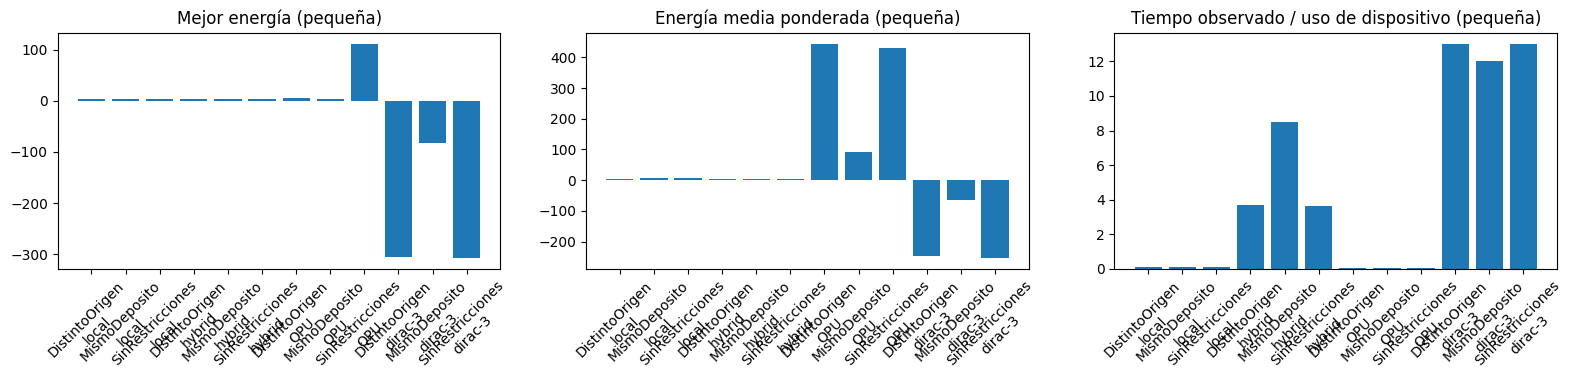

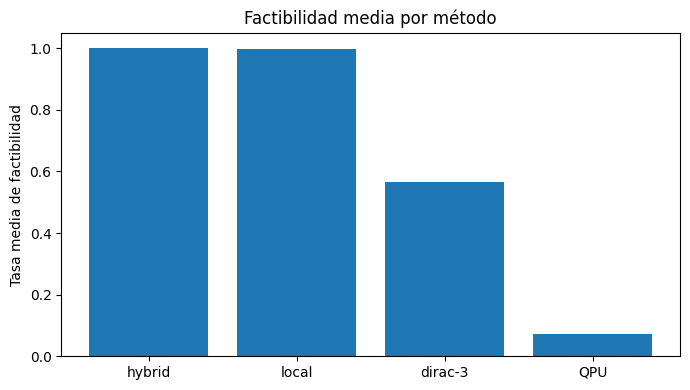

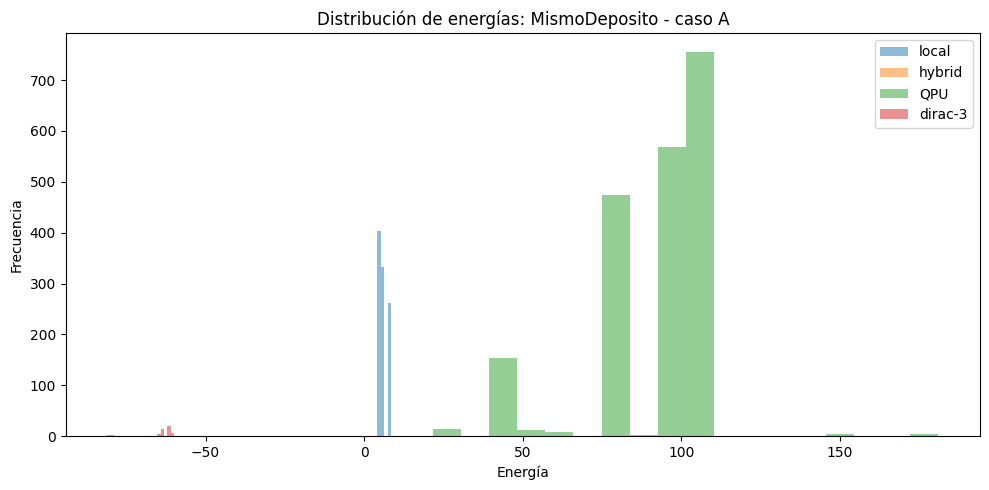

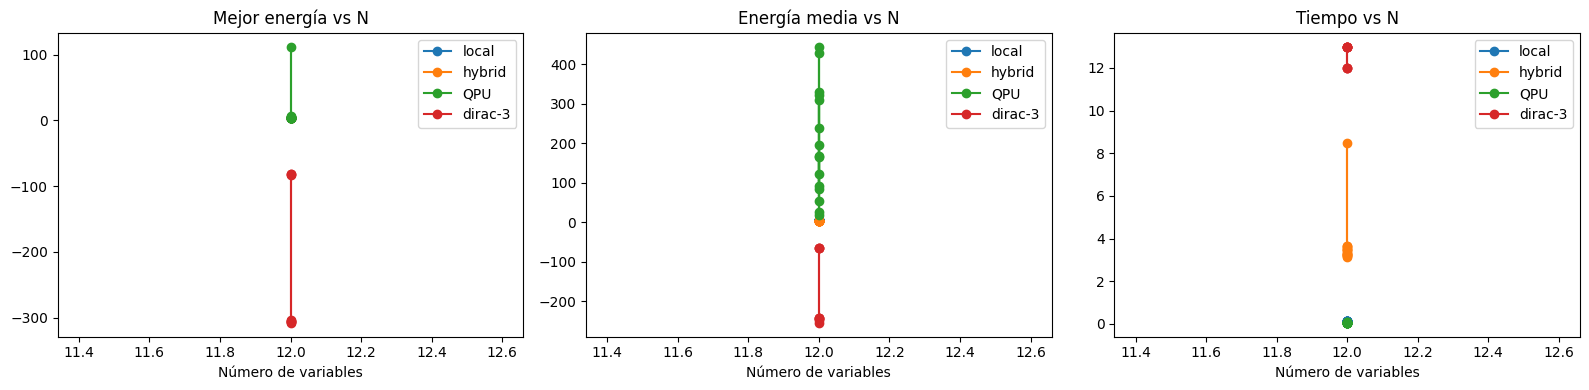

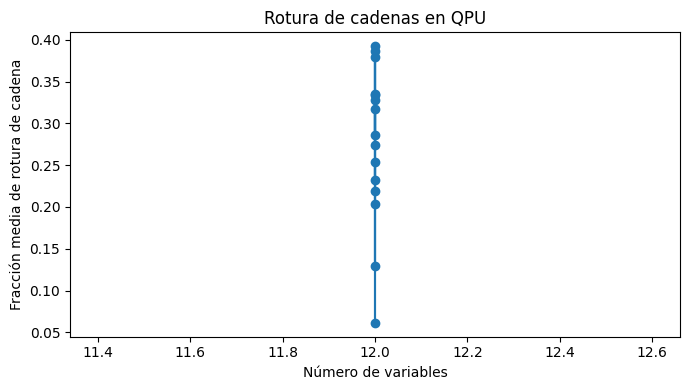

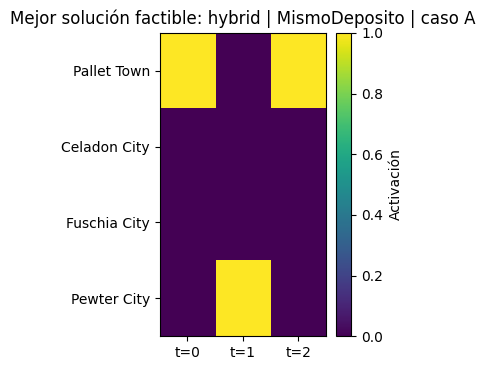

In [8]:
graficar_resumen(tabla_resumen, tamaño="pequeña")

graficar_tasa_factibilidad(tabla_resumen)

graficar_distribucion_energias_instancia(
    muestras_por_ejecucion,
    problema="MismoDeposito",
    caso="A"
)

graficar_escalado_por_tamano(tabla_resumen)

graficar_rotura_cadenas_qpu(tabla_resumen)

graficar_mapa_mejor_solucion_factible(
    muestras_por_ejecucion,
    metadatos_por_ejecucion,
    metodo="hybrid",
    problema="MismoDeposito",
    caso="A"
)

In [9]:
tabla = tabla_resumen[[
    "metodo", "problema", "caso", "tamaño", "N",
    "mejor_energia", "energia_media_ponderada", "desviacion_energia_ponderada",
    "tasa_factibilidad", "mejor_energia_factible",
    "tiempo_total_s", "tiempo_uso_dispositivo_s",
    "fraccion_media_rotura_cadena",
    "mejor_ruta_factible"
]].sort_values(["tamaño", "problema", "metodo"])

display(tabla)

,metodo,problema,caso,tamaño,N,mejor_energia,energia_media_ponderada,desviacion_energia_ponderada,tasa_factibilidad,mejor_energia_factible,tiempo_total_s,tiempo_uso_dispositivo_s,fraccion_media_rotura_cadena,mejor_ruta_factible
30,QPU,DistintoOrigen,A,pequeña,12,6.0,444.818500,179.500222,0.000500,6.0,0.057199,NaN,0.327458,Vehículo 0: Pallet Town -> Pewter City -> Fusc...
33,QPU,DistintoOrigen,A,pequeña,12,4.0,197.034500,118.935976,0.001500,4.0,0.061404,NaN,0.253458,Vehículo 0: Pallet Town -> Pewter City -> Pall...
36,QPU,DistintoOrigen,A,pequeña,12,4.0,329.451500,97.492054,0.002000,4.0,0.048575,NaN,0.379708,Vehículo 0: Pallet Town -> Pewter City -> Pall...
39,QPU,DistintoOrigen,A,pequeña,12,4.0,168.598500,76.752800,0.001000,4.0,0.051153,NaN,0.335500,Vehículo 0: Pallet Town -> Pewter City -> Pall...
42,QPU,DistintoOrigen,A,pequeña,12,4.0,240.008000,212.909640,0.155500,4.0,0.060658,NaN,0.285917,Vehículo 0: Pallet Town -> Pewter City -> Pall...
45,dirac-3,DistintoOrigen,A,pequeña,12,-306.0,-245.620000,37.211229,0.800000,-306.0,22.320000,13.0,NaN,Vehículo 0: Pallet Town -> Pewter City -> Pall...
46,dirac-3,DistintoOrigen,B,pequeña,12,-305.0,-243.200000,36.010554,0.860000,-305.0,22.244000,13.0,NaN,Vehículo 0: Pallet Town -> Saffron City -> Cel...
47,dirac-3,DistintoOrigen,C,pequeña,12,-304.0,-242.640000,33.840662,0.760000,-304.0,21.593000,13.0,NaN,Vehículo 0: Pallet Town -> Vermillion City -> ...
15,hybrid,DistintoOrigen,A,pequeña,12,4.0,4.000000,0.000000,1.000000,4.0,3.191770,NaN,NaN,Vehículo 0: Pallet Town -> Pewter City -> Pall...
18,hybrid,DistintoOrigen,A,pequeña,12,4.0,4.000000,0.000000,1.000000,4.0,3.668660,NaN,NaN,Vehículo 0: Pallet Town -> Pewter City -> Pall...


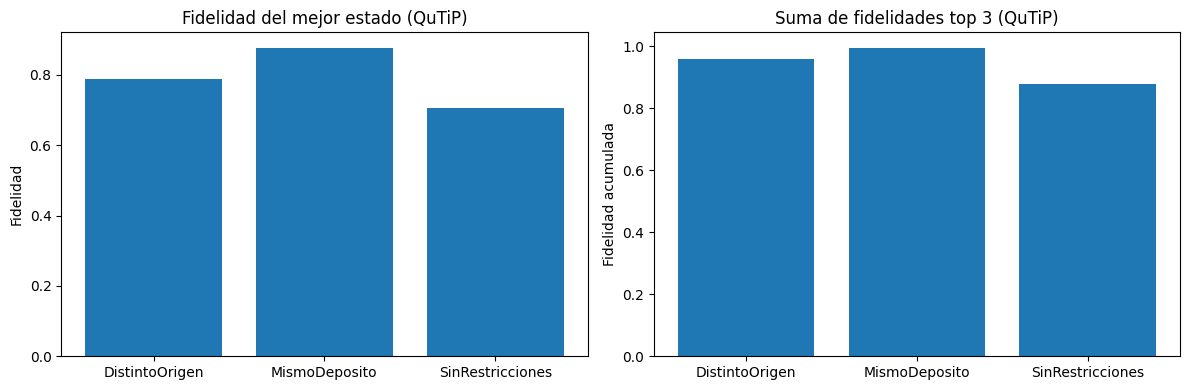

In [11]:
graficar_fidelidades_qutip(tabla_agregada)